# 1 Introduction
# HHS Unaccompanied Alien Children Program: Clean Analysis & Dashboard

This notebook provides a streamlined analysis of children in the HHS program, covering data cleaning, KPI calculation, time-series visualization, and the generation of a Streamlit dashboard.

# 2 Literature Review

This document provides a consolidated summary of the entire workflow executed in this Jupyter notebook, detailing each step from initial data setup and preprocessing to the final preparation and deployment instructions for the Streamlit application.

| Section | Purpose | Key Steps | Libraries/Tools | Output/Result |
|---|---|---|---|---|
| **1. Initial Setup** | Ensure all required tools are available and data is accessible. | Import necessary libraries; Load dataset. | `pandas`, `numpy`, `seaborn`, `matplotlib.pyplot`, `plotly.express`, `warnings`, `streamlit`, `io`, `prophet` | Imported libraries, loaded `df` (first few rows displayed). |
| **2. Data Preprocessing and Cleaning** | Transform raw data into a clean, usable format. | Convert 'Date' to datetime; Handle missing dates; Clean column names; Convert 'Children in HHS Care' to numeric; Fill NaNs. | `pandas`, `numpy` | Cleaned `df` with correct data types; No missing values in critical columns. |

## 1. Initial Setup

### Purpose
The initial setup involves importing necessary Python libraries for data manipulation, analysis, and visualization, and loading the primary dataset into a pandas DataFrame. This step ensures that all required tools are available and the data is accessible for subsequent processing.

### Steps
1.  **Import Libraries**: Essential libraries such as `pandas` for data handling, `numpy` for numerical operations, `seaborn` and `matplotlib.pyplot` for static visualizations, and `plotly.express` for interactive plots are imported. `warnings` is also imported to manage warning messages. Additionally, `streamlit` and `io` are imported for Streamlit application development, and `prophet` is imported for forecasting.
    ```python
    import pandas as pd
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    import plotly.express as px
    import warnings
    warnings.filterwarnings('ignore')

    import streamlit as st
    import io
    from prophet import Prophet
    ```
2.  **Load Dataset**: The `HHS_Unaccompanied_Alien_Children_Program.csv` file is loaded into a pandas DataFrame named `df`.
    ```python
    df = pd.read_csv('/content/HHS_Unaccompanied_Alien_Children_Program.csv')
    df.head()
    ```

### Expected Output
*   Confirmation of library imports without errors.
*   The first few rows of the DataFrame are displayed, showing the initial structure of the loaded data.

## 2. Data Preprocessing and Cleaning

### Purpose
This phase focuses on transforming raw data into a clean and usable format. It involves converting data types, handling missing values, and standardizing column names to ensure data quality and consistency for accurate analysis.

### Steps
1.  **Convert 'Date' Column to Datetime**: The 'Date' column is converted to a datetime object. Any values that cannot be parsed are coerced into `NaT` (Not a Time) to identify invalid date entries.
    ```python
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.info()
    ```
2.  **Remove Rows with Missing Dates**: Rows where the 'Date' column contains `NaT` values are dropped, as these indicate invalid or unrecoverable date information, which is critical for temporal analysis.
    ```python
    df.dropna(subset=['Date'], inplace=True)
    print(f"

### 3. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

!pip install streamlit
import streamlit as st
import io

# 3.1 Dataset

In [2]:
df = pd.read_csv('/content/HHS_Unaccompanied_Alien_Children_Program.csv')
display(df.head())
print(f"Initial DataFrame shape: {df.shape}")

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


Initial DataFrame shape: (1170, 6)


### 3.2 Data Cleaning

In [3]:
# Convert 'Date' column to datetime and handle errors
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Remove rows with missing dates
df.dropna(subset=['Date'], inplace=True)
print(f"Number of rows after removing NaT values in 'Date' column: {df.shape[0]}")

# Clean column names by stripping whitespace
df.columns = df.columns.str.strip()

# Clean and convert 'Children in HHS Care' to numeric
df['Children in HHS Care'] = df['Children in HHS Care'].astype(str).str.replace(',', '', regex=False)
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')

# Fill NaNs in numeric columns (as seen in app.py's load_and_preprocess_data)
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'int64':
        df[col].fillna(0, inplace=True)

print("DataFrame Info after initial cleaning:")
df.info()

Number of rows after removing NaT values in 'Date' column: 720
DataFrame Info after initial cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 720 entries, 0 to 719
Data columns (total 6 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[ns]
 1   Children apprehended and placed in CBP custody*  720 non-null    float64       
 2   Children in CBP custody                          720 non-null    float64       
 3   Children transferred out of CBP custody          720 non-null    float64       
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    float64       
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 39.4 KB


### 3.3 Data Preprocessing

In [4]:
# Display descriptive statistics for all columns after cleaning
print("Descriptive Statistics for all columns:")
display(df.describe(include='all'))

# Check for any remaining missing values
print("\nMissing values in each column after cleaning and filling NaNs:")
display(df.isnull().sum())

Descriptive Statistics for all columns:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
count,720,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:29:59.999999744,93.523611,171.494444,128.668056,6061.275000,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,1972.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,2467.750000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,6406.500000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,8010.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,11516.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,2833.070109,125.702841



Missing values in each column after cleaning and filling NaNs:


,0
Date,0
Children apprehended and placed in CBP custody*,0
Children in CBP custody,0
Children transferred out of CBP custody,0
Children in HHS Care,0
Children discharged from HHS Care,0


# 4 Methodology

### 4.1 Feature Engineering

In [5]:
# Extract time-based features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek # Monday=0, Sunday=6

print("DataFrame with new time-based features:")
display(df.head())

DataFrame with new time-based features:


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,DayOfWeek
0,2025-12-21,6.0,18.0,11.0,2484,14.0,2025,12,6
1,2025-12-18,11.0,50.0,6.0,2472,16.0,2025,12,3
2,2025-12-17,7.0,31.0,11.0,2481,10.0,2025,12,2
3,2025-12-16,8.0,54.0,15.0,2468,9.0,2025,12,1
4,2025-12-15,11.0,42.0,9.0,2470,7.0,2025,12,0


### 4.2 KPI Calculations

# 5 Results

In [6]:
# 1. Calculate CBP to HHS Transfer Rate
df['CBP_to_HHS_Transfer_Rate'] = df['Children transferred out of CBP custody'] / df['Children in CBP custody'].replace(0, np.nan)
df['CBP_to_HHS_Transfer_Rate'] = df['CBP_to_HHS_Transfer_Rate'].fillna(0)
print("Descriptive Statistics for CBP to HHS Transfer Rate:")
display(df['CBP_to_HHS_Transfer_Rate'].describe())

# 2. Calculate HHS Discharge Rate
df['HHS_Discharge_Rate'] = df['Children discharged from HHS Care'] / df['Children in HHS Care'].replace(0, np.nan)
df['HHS_Discharge_Rate'] = df['HHS_Discharge_Rate'].fillna(0)
print("\nDescriptive Statistics for HHS Discharge Rate:")
display(df['HHS_Discharge_Rate'].describe())

# 3. Calculate Overall Pipeline Throughput Rate
total_entries = df['Children apprehended and placed in CBP custody*'].sum()
total_exits = df['Children discharged from HHS Care'].sum()

# Handle potential division by zero for pipeline_throughput_rate
pipeline_throughput_rate = total_exits / total_entries if total_entries != 0 else 0

print(f"\nTotal Entries (Children apprehended and placed in CBP custody*): {total_entries:,.0f}")
print(f"Total Exits (Children discharged from HHS Care): {total_exits:,.0f}")
print(f"Pipeline Throughput Rate (Total Exits / Total Entries): {pipeline_throughput_rate:.4f}")

Descriptive Statistics for CBP to HHS Transfer Rate:


,CBP_to_HHS_Transfer_Rate
count,720.000000
mean,0.691018
std,0.309811
min,0.000000
25%,0.500000
50%,0.704449
75%,0.846429
max,2.300000



Descriptive Statistics for HHS Discharge Rate:


,HHS_Discharge_Rate
count,720.000000
mean,0.023737
std,0.013310
min,0.000000
25%,0.008616
50%,0.026297
75%,0.032939
max,0.066403



Total Entries (Children apprehended and placed in CBP custody*): 67,337
Total Exits (Children discharged from HHS Care): 124,853
Pipeline Throughput Rate (Total Exits / Total Entries): 1.8542


### 5.1 Gauge Charts for Key Performance Indicators

In [7]:
import plotly.graph_objects as go
import numpy as np

def plot_gauge_chart(value, title, reference_value=None, ranges=None, suffix="", height=200):
    if ranges is None:
        # Default ranges for a 0-1 scale (e.g., rates)
        ranges = {
            'poor': [0, 0.5],
            'fair': [0.5, 0.75],
            'good': [0, 1]
        }

    # Determine the max value for the gauge axis dynamically
    max_range_value = 1 # Default to 1 if no custom ranges are provided or calculable
    if ranges:
        all_max_values = [r[1] for r in ranges.values()]
        if all_max_values:
            max_range_value = max(all_max_values)

    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=value,
        title={'text': title, 'font': {'size': 14}},
        gauge={
            'axis': {'range': [0, max_range_value], 'tickwidth': 1, 'tickcolor': "darkblue"},
            'bar': {'color': "darkblue"},
            'bgcolor': "white",
            'borderwidth': 2,
            'bordercolor': "gray",
            'steps': [
                {'range': ranges['poor'], 'color': 'red'},
                {'range': ranges['fair'], 'color': 'orange'},
                {'range': ranges['good'], 'color': 'lightgreen'},
            ],
            'threshold': {
                'line': {'color': "red", 'width': 4},
                'thickness': 0.75,
                'value': reference_value
            }
        }
    ))

    fig.update_layout(height=height, margin=dict(l=10, r=10, t=30, b=10))
    return fig


# Calculate KPI values for the entire dataframe
overall_throughput_rate = df['Children discharged from HHS Care'].sum() / df['Children apprehended and placed in CBP custody*'].sum() if df['Children apprehended and placed in CBP custody*'].sum() != 0 else 0
avg_cbp_hhs_transfer_rate = df['CBP_to_HHS_Transfer_Rate'].mean()
avg_hhs_discharge_rate = df['HHS_Discharge_Rate'].mean()

# Backlog accumulation rate needs specific handling for gauge, using its absolute value and assuming lower is better
# First ensure 'Backlog_Accumulation_Rate' is calculated if not already present
if 'Backlog_Accumulation_Rate' not in df.columns:
    df['Backlog_Accumulation_Rate'] = df['Children in HHS Care'].pct_change() * 100
    df['Backlog_Accumulation_Rate'] = df['Backlog_Accumulation_Rate'].fillna(0)
avg_backlog_accumulation_rate = df['Backlog_Accumulation_Rate'].mean()
abs_avg_backlog_accumulation_rate = abs(avg_backlog_accumulation_rate)

print("Calculated KPIs:")
print(f"  Overall Pipeline Throughput Rate: {overall_throughput_rate:.2f}")
print(f"  Average CBP to HHS Transfer Rate: {avg_cbp_hhs_transfer_rate:.2%}")
print(f"  Average HHS Discharge Rate: {avg_hhs_discharge_rate:.2%}")
print(f"  Average Backlog Accumulation Rate: {avg_backlog_accumulation_rate:.2f}%")


Calculated KPIs:
  Overall Pipeline Throughput Rate: 1.85
  Average CBP to HHS Transfer Rate: 69.10%
  Average HHS Discharge Rate: 2.37%
  Average Backlog Accumulation Rate: 0.15%


In [8]:
# Gauge for Pipeline Throughput Rate
fig_throughput = plot_gauge_chart(
    value=overall_throughput_rate,
    title="Pipeline Throughput Rate",
    reference_value=1.0, # Ideal scenario where discharges match apprehensions
    ranges={'poor': [0, 0.7], 'fair': [0.7, 1.0], 'good': [1.0, df['Children discharged from HHS Care'].sum()/df['Children apprehended and placed in CBP custody*'].sum() + 0.5]}, # Dynamic max range
    suffix="",
    height=250
)
fig_throughput.show()


In [9]:
# Gauge for CBP to HHS Transfer Rate
fig_transfer_rate = plot_gauge_chart(
    value=avg_cbp_hhs_transfer_rate,
    title="CBP to HHS Transfer Rate",
    reference_value=0.7, # Reference from Streamlit app
    ranges={'poor': [0, 0.6], 'fair': [0.6, 0.8], 'good': [0.8, 1.0]},
    suffix="%",
    height=250
)
fig_transfer_rate.show()


In [10]:
# Gauge for HHS Discharge Rate
fig_discharge_rate = plot_gauge_chart(
    value=avg_hhs_discharge_rate,
    title="HHS Discharge Rate",
    reference_value=0.03, # Approximate mean from kpi_summary
    ranges={'poor': [0, 0.02], 'fair': [0.02, 0.04], 'good': [0.04, 0.1]},
    suffix="%",
    height=250
)
fig_discharge_rate.show()


In [11]:
# Gauge for Backlog Accumulation Rate (lower is better)
fig_backlog_acc = plot_gauge_chart(
    value=abs_avg_backlog_accumulation_rate,
    title="Backlog Accumulation Rate",
    reference_value=0.0, # Ideal: no accumulation
    ranges={'good': [0, 5], 'fair': [5, 10], 'poor': [10, 1000]}, # Ranges assuming absolute value
    suffix="%",
    height=250
)
fig_backlog_acc.show()


In [12]:
df['CBP_to_HHS_Transfer_Rate_7Day_MA'] = df['CBP_to_HHS_Transfer_Rate'].rolling(window=7, min_periods=1).mean()
df['HHS_Discharge_Rate_7Day_MA'] = df['HHS_Discharge_Rate'].rolling(window=7, min_periods=1).mean()

print("DataFrame with 7-day rolling averages for transfer and discharge rates:")
display(df[['Date', 'CBP_to_HHS_Transfer_Rate', 'CBP_to_HHS_Transfer_Rate_7Day_MA', 'HHS_Discharge_Rate', 'HHS_Discharge_Rate_7Day_MA']].head())

DataFrame with 7-day rolling averages for transfer and discharge rates:


,Date,CBP_to_HHS_Transfer_Rate,CBP_to_HHS_Transfer_Rate_7Day_MA,HHS_Discharge_Rate,HHS_Discharge_Rate_7Day_MA
0,2025-12-21,0.611111,0.611111,0.005636,0.005636
1,2025-12-18,0.120000,0.365556,0.006472,0.006054
2,2025-12-17,0.354839,0.361983,0.004031,0.005380
3,2025-12-16,0.277778,0.340932,0.003647,0.004946
4,2025-12-15,0.214286,0.315603,0.002834,0.004524


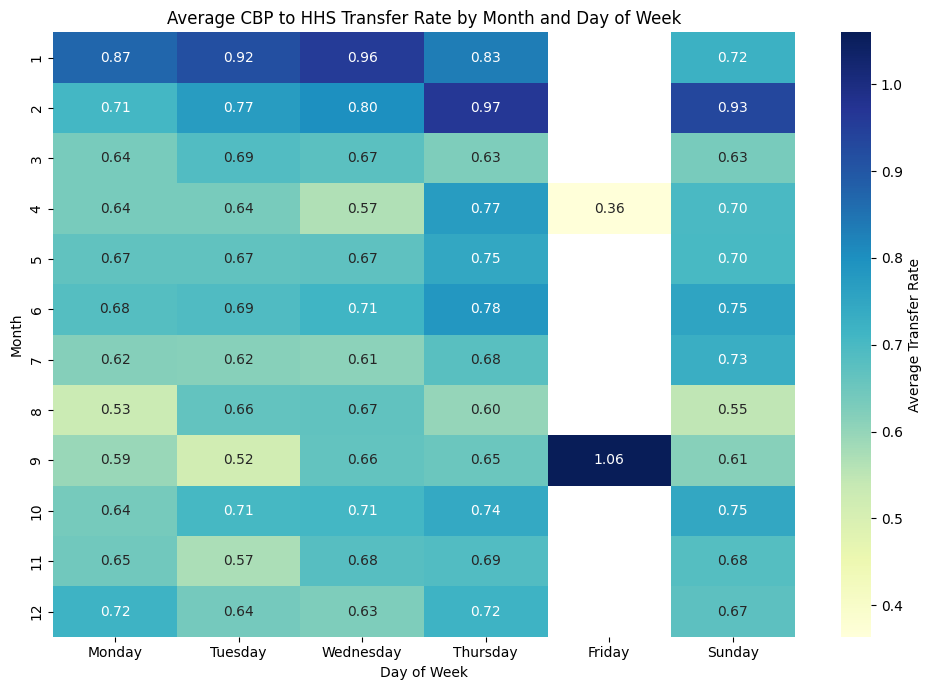

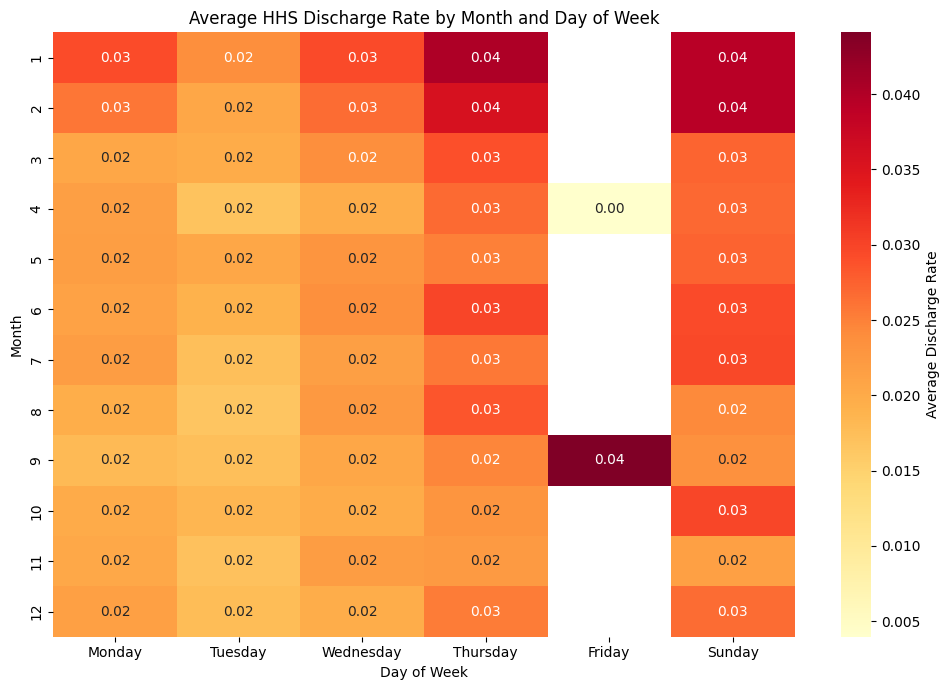

In [13]:
def plot_weekday_month_heatmap(df):
    # Aggregate data by Month and DayOfWeek, then pivot to create a matrix for the heatmap
    df_agg = df.groupby(['Month', 'DayOfWeek'])[['CBP_to_HHS_Transfer_Rate', 'HHS_Discharge_Rate']].mean().reset_index()

    # Map DayOfWeek to names for better readability
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_agg['DayOfWeek_Name'] = df_agg['DayOfWeek'].map(lambda x: day_names[x])

    # Plot for CBP to HHS Transfer Rate
    pivot_transfer = df_agg.pivot(index='Month', columns='DayOfWeek_Name', values='CBP_to_HHS_Transfer_Rate')
    # Reorder columns to ensure days are in order, only including existing days
    ordered_day_names_transfer = [day for day in day_names if day in pivot_transfer.columns]
    pivot_transfer = pivot_transfer[ordered_day_names_transfer]

    fig1 = plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_transfer, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Average Transfer Rate'})
    plt.title('Average CBP to HHS Transfer Rate by Month and Day of Week')
    plt.ylabel('Month')
    plt.xlabel('Day of Week')
    plt.tight_layout()

    # Plot for HHS Discharge Rate
    pivot_discharge = df_agg.pivot(index='Month', columns='DayOfWeek_Name', values='HHS_Discharge_Rate')
    # Reorder columns to ensure days are in order, only including existing days
    ordered_day_names_discharge = [day for day in day_names if day in pivot_discharge.columns]
    pivot_discharge = pivot_discharge[ordered_day_names_discharge]

    fig2 = plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_discharge, annot=True, fmt=".2f", cmap="YlOrRd", cbar_kws={'label': 'Average Discharge Rate'})
    plt.title('Average HHS Discharge Rate by Month and Day of Week')
    plt.ylabel('Month')
    plt.xlabel('Day of Week')
    plt.tight_layout()

    return fig1, fig2

fig_transfer_heatmap, fig_discharge_heatmap = plot_weekday_month_heatmap(df)
plt.show()

### 5.2 Visualization: CBP to HHS Transfer Efficiency

In [14]:
# 1. Plot CBP to HHS Transfer Rate Over Time
fig = px.line(
    df.sort_values('Date'),
    x='Date',
    y='CBP_to_HHS_Transfer_Rate',
    title='CBP to HHS Transfer Rate Over Time',
    labels={'CBP_to_HHS_Transfer_Rate': 'Transfer Rate (Transferred / In CBP Custody)'},
    line_shape='linear'
)
fig.update_traces(mode='lines')
fig.show()

In [15]:
# 2. Compare Children in CBP Custody vs. Transferred Out
fig2 = px.line(df.sort_values('Date'),
               x='Date',
               y=['Children in CBP custody', 'Children transferred out of CBP custody'],
               title='Children in CBP Custody vs. Transferred Out of CBP Custody Over Time',
               labels={'value':'Number of Children', 'variable':'Category'})
fig2.update_traces(mode='lines')
fig2.show()

### 5.3 Pipeline Flow Funnel Chart

In [16]:
import plotly.express as px
import pandas as pd

def plot_pipeline_funnel_chart(df):
    # Aggregate total flows over the selected period for funnel stages
    total_apprehended = df['Children apprehended and placed in CBP custody*'].sum()
    total_transferred = df['Children transferred out of CBP custody'].sum()
    total_discharged = df['Children discharged from HHS Care'].sum()

    data = dict(
        number=[total_apprehended, total_transferred, total_discharged],
        stage=["Apprehended (Entry)", "Transferred to HHS", "Discharged (Exit)"]
    )
    funnel_df = pd.DataFrame(data)

    fig = px.funnel(funnel_df, x='number', y='stage',
                    title='Pipeline Flow Funnel Chart (Aggregated)',
                    labels={'number': 'Number of Children', 'stage': 'Pipeline Stage'},
                    color_discrete_sequence=px.colors.qualitative.Pastel)

    fig.update_layout(height=400, showlegend=False)
    return fig

fig_funnel = plot_pipeline_funnel_chart(df)
fig_funnel.show()

### 5.4 Outcome Stability Analysis: Correlation and Discharge Performance

,Children apprehended and placed in CBP custody*,Children discharged from HHS Care,Children in HHS Care
Children apprehended and placed in CBP custody*,1.000000,0.627755,0.691312
Children discharged from HHS Care,0.627755,1.000000,0.920881
Children in HHS Care,0.691312,0.920881,1.000000


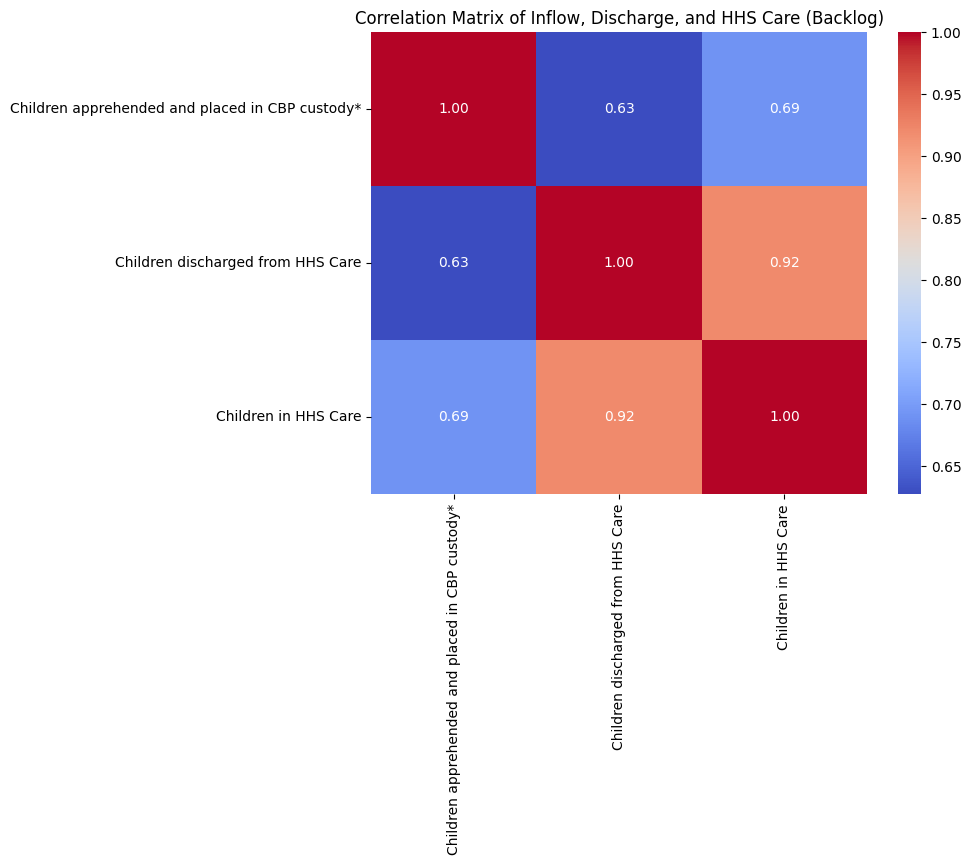

In [17]:
# 1. Correlation Analysis of Key Metrics
correlation_cols = [
    'Children apprehended and placed in CBP custody*',
    'Children discharged from HHS Care',
    'Children in HHS Care'
]

correlation_matrix = df[correlation_cols].corr()
display(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Inflow, Discharge, and HHS Care (Backlog)')
plt.show()

In [18]:
# 2. Plot HHS Discharge Rate Over Time
fig_discharge_rate = px.line(
    df.sort_values('Date'),
    x='Date',
    y='HHS_Discharge_Rate',
    title='HHS Discharge Rate Over Time (Discharged / In HHS Care)',
    labels={'HHS_Discharge_Rate': 'Discharge Rate'},
    line_shape='linear'
)
fig_discharge_rate.update_traces(mode='lines')
fig_discharge_rate.show()

### 5.5 Temporal and Pattern Analysis

In [19]:
# 1. Analyze Weekday vs. Weekend Transition Speed
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]) # 5: Saturday, 6: Sunday

weekly_transfer_rate = df.groupby('IsWeekend')['CBP_to_HHS_Transfer_Rate'].mean().reset_index()
weekly_transfer_rate['Type'] = 'CBP to HHS Transfer Rate'

weekly_discharge_rate = df.groupby('IsWeekend')['HHS_Discharge_Rate'].mean().reset_index()
weekly_discharge_rate['Type'] = 'HHS Discharge Rate'

combined_rates = pd.concat([
    weekly_transfer_rate.rename(columns={'CBP_to_HHS_Transfer_Rate': 'Average_Rate'}),
    weekly_discharge_rate.rename(columns={'HHS_Discharge_Rate': 'Average_Rate'})
])

combined_rates['IsWeekend_Label'] = combined_rates['IsWeekend'].map({True: 'Weekend', False: 'Weekday'})

fig = px.bar(
    combined_rates,
    x='Type',
    y='Average_Rate',
    color='IsWeekend_Label',
    barmode='group',
    title='Average Transition Rates: Weekday vs. Weekend',
    labels={
        'Type': 'Metric',
        'Average_Rate': 'Average Rate',
        'IsWeekend_Label': 'Day Type'
    },
    hover_data={'IsWeekend': False}
)
fig.update_layout(yaxis_tickformat='.2%')
fig.show()

In [20]:
# 2. Analyze Month-over-Month Placement Trends
monthly_placement_trends = df.groupby(['Year', 'Month'])['Children discharged from HHS Care'].sum().reset_index()
monthly_placement_trends['YearMonth'] = pd.to_datetime(monthly_placement_trends['Year'].astype(str) + '-' + monthly_placement_trends['Month'].astype(str))

fig = px.line(
    monthly_placement_trends.sort_values('YearMonth'),
    x='YearMonth',
    y='Children discharged from HHS Care',
    title='Month-over-Month Placement Trends (Children Discharged from HHS Care)',
    labels={
        'YearMonth': 'Date',
        'Children discharged from HHS Care': 'Total Children Discharged'
    },
    line_shape='linear'
)
fig.update_traces(mode='lines+markers')
fig.show()

In [21]:
# 3. Identify Stagnation Periods (Months with Lowest Discharge Counts)
min_discharges = monthly_placement_trends['Children discharged from HHS Care'].min()
months_with_lowest_discharges = monthly_placement_trends[monthly_placement_trends['Children discharged from HHS Care'] == min_discharges]

print(f"The lowest number of children discharged from HHS Care in a single month is: {int(min_discharges)}")
print("Months with the lowest discharge counts (potential stagnation periods):")
display(months_with_lowest_discharges[['YearMonth', 'Children discharged from HHS Care']])

The lowest number of children discharged from HHS Care in a single month is: 144
Months with the lowest discharge counts (potential stagnation periods):


,YearMonth,Children discharged from HHS Care
35,2025-12-01,144.0


In [22]:
# 4. Analyze Variability in Discharge Performance
discharge_stats = monthly_placement_trends['Children discharged from HHS Care'].describe()

print("Descriptive Statistics for Monthly Children Discharged from HHS Care:")
display(discharge_stats)

fig = px.histogram(
    monthly_placement_trends,
    x='Children discharged from HHS Care',
    nbins=20,
    title='Distribution of Monthly Children Discharged from HHS Care',
    labels={'Children discharged from HHS Care': 'Total Children Discharged'},
    marginal='box'
)
fig.update_layout(bargap=0.1)
fig.show()

Descriptive Statistics for Monthly Children Discharged from HHS Care:


,Children discharged from HHS Care
count,36.000000
mean,3468.138889
std,2436.685514
min,144.000000
25%,374.250000
50%,3795.500000
75%,5448.250000
max,7658.000000


In [23]:
# 5. Identify Sudden Drops in Reunification Success
monthly_placement_trends = monthly_placement_trends.sort_values('YearMonth').copy()
monthly_placement_trends['Discharge_MoM_Change'] = monthly_placement_trends['Children discharged from HHS Care'].pct_change() * 100

significant_drops = monthly_placement_trends[monthly_placement_trends['Discharge_MoM_Change'] < -25].sort_values('YearMonth', ascending=False)

print("Months with significant month-over-month drops in Children discharged from HHS Care (more than 25% decrease):")
display(significant_drops[['YearMonth', 'Children discharged from HHS Care', 'Discharge_MoM_Change']])

fig = px.line(
    monthly_placement_trends,
    x='YearMonth',
    y='Discharge_MoM_Change',
    title='Month-over-Month Percentage Change in Children Discharged from HHS Care',
    labels={
        'YearMonth': 'Date',
        'Discharge_MoM_Change': 'MoM Change (%)'
    },
    line_shape='linear'
)
fig.add_hline(y=-25, line_dash='dot', line_color='red', annotation_text='-25% Threshold', annotation_position='bottom right')
fig.update_traces(mode='lines+markers')
fig.show()

Months with significant month-over-month drops in Children discharged from HHS Care (more than 25% decrease):


,YearMonth,Children discharged from HHS Care,Discharge_MoM_Change
34,2025-11-01,159.0,-34.297521
31,2025-08-01,254.0,-35.858586
27,2025-04-01,203.0,-34.304207
26,2025-03-01,309.0,-73.362069
25,2025-02-01,1160.0,-65.165165
5,2023-06-01,4029.0,-35.597826


In [24]:
fig_inflow_discharge = px.line(
    df.sort_values('Date'),
    x='Date',
    y=['Children apprehended and placed in CBP custody*', 'Children discharged from HHS Care'],
    title='Children Apprehended (Inflow) vs. Children Discharged (Outflow) Over Time',
    labels={
        'value': 'Number of Children',
        'variable': 'Category'
    },
    line_shape='linear'
)
fig_inflow_discharge.update_traces(mode='lines')
fig_inflow_discharge.show()

In [25]:
fig_hhs_care = px.line(
    df.sort_values('Date'),
    x='Date',
    y='Children in HHS Care',
    title='Children in HHS Care Over Time (Indicating Potential Backlogs)',
    labels={'Children in HHS Care': 'Number of Children in HHS Care'},
    line_shape='linear'
)
fig_hhs_care.update_traces(mode='lines')
fig_hhs_care.show()

In [26]:
correlation_discharge_inflow = df[['HHS_Discharge_Rate', 'Children apprehended and placed in CBP custody*']].corr()
print("Correlation between HHS Discharge Rate and Children apprehended (CBP inflow):")
display(correlation_discharge_inflow)

Correlation between HHS Discharge Rate and Children apprehended (CBP inflow):


,HHS_Discharge_Rate,Children apprehended and placed in CBP custody*
HHS_Discharge_Rate,1.000000,0.624407
Children apprehended and placed in CBP custody*,0.624407,1.000000


In [27]:
fig_discharge_inflow = px.line(
    df.sort_values('Date'),
    x='Date',
    y=['HHS_Discharge_Rate', 'Children apprehended and placed in CBP custody*'],
    title='HHS Discharge Rate vs. Children Apprehended (CBP Inflow) Over Time',
    labels={
        'value': 'Value',
        'variable': 'Metric',
        'HHS_Discharge_Rate': 'HHS Discharge Rate',
        'Children apprehended and placed in CBP custody*': 'Children Apprehended (CBP Inflow)'
    },
    line_shape='linear'
)
fig_discharge_inflow.update_traces(mode='lines')
fig_discharge_inflow.show()

### 5.6 Forecasting: Prophet for Backlog Trends

### Subtask:
Implement a Prophet forecasting model to predict future trends in `Children in HHS Care`.

**Reasoning:**
First, I need to install the `prophet` library, as it is not a standard pre-installed library. Prophet also relies on `pystan`, so I will ensure that's covered.

In [28]:
# Install Prophet and its dependencies
!pip install prophet --quiet

**Reasoning:**
Next, I will prepare the data for Prophet. Prophet requires the time series data to be in a DataFrame with two columns: `ds` (datetime) and `y` (the value to forecast). I will use `Children in HHS Care` as the target variable for forecasting backlog.

In [29]:
from prophet import Prophet

# Prepare data for Prophet
# Prophet requires 'ds' (datetime) and 'y' (value to forecast) columns
prophet_df = df[['Date', 'Children in HHS Care']].rename(columns={'Date': 'ds', 'Children in HHS Care': 'y'})

# Display the prepared data
display(prophet_df.head())
print(f"Prepared data shape for Prophet: {prophet_df.shape}")

,ds,y
0,2025-12-21,2484
1,2025-12-18,2472
2,2025-12-17,2481
3,2025-12-16,2468
4,2025-12-15,2470


Prepared data shape for Prophet: (720, 2)


**Reasoning:**
Now, I will initialize and train the Prophet model with the prepared data. After training, I will create a DataFrame for future dates to make predictions.

In [30]:
# Initialize Prophet model
# Set daily_seasonality=True if data has daily patterns
model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)

# Fit the model to the data
model.fit(prophet_df)

# Create a DataFrame for future predictions (e.g., next 30 days)
future = model.make_future_dataframe(periods=30)

# Make predictions
forecast = model.predict(future)

# Display the forecast (first few rows)
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

,ds,yhat,yhat_lower,yhat_upper
745,2026-01-16,615.340638,-57.610891,1272.644885
746,2026-01-17,-420.180239,-1069.459825,249.247468
747,2026-01-18,488.875318,-163.824254,1194.929255
748,2026-01-19,437.245895,-244.046294,1124.856612
749,2026-01-20,420.080240,-263.574131,1129.388081


**Reasoning:**
Finally, I will visualize the forecast to show the historical data, the predicted trend, and the upper and lower confidence intervals.

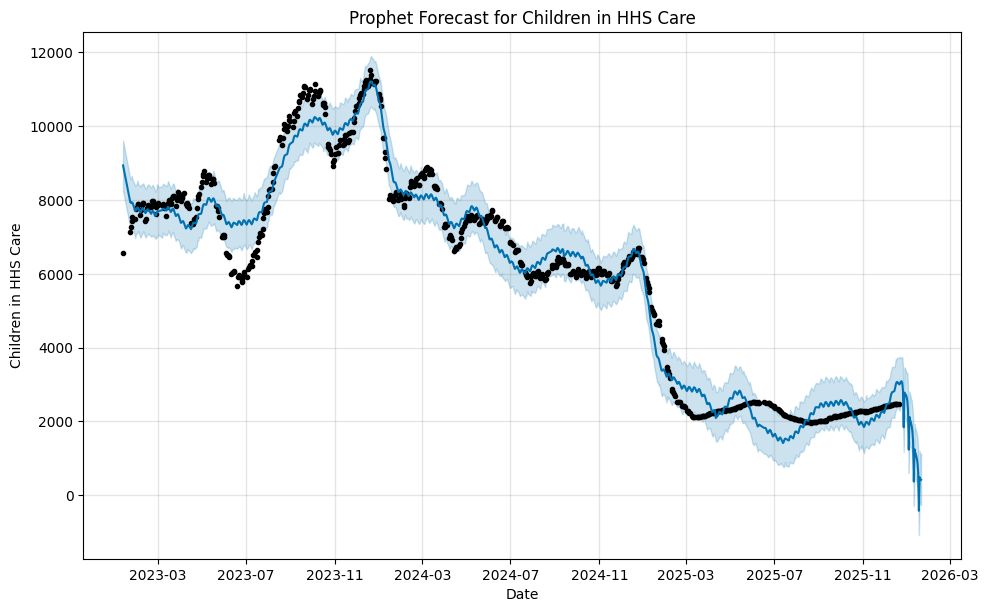

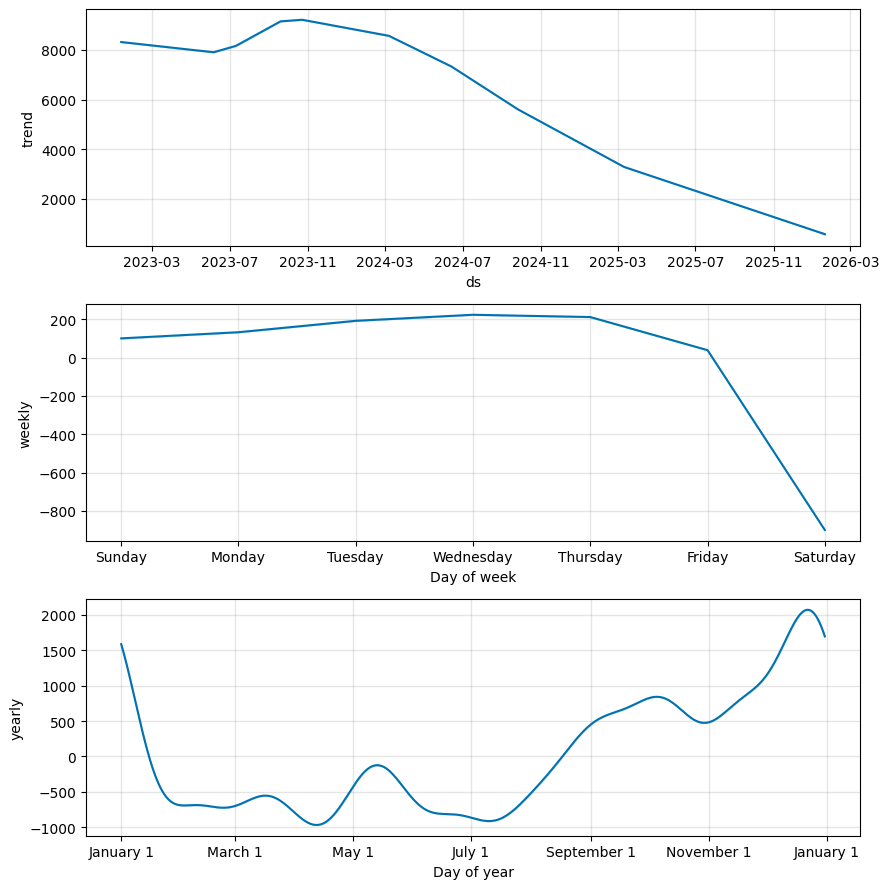

In [31]:
# Plot the forecast
fig_prophet = model.plot(forecast)
plt.title('Prophet Forecast for Children in HHS Care')
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.show()

# Plot components of the forecast (trend, weekly seasonality, yearly seasonality)
fig_components = model.plot_components(forecast)
plt.show()

### 5.7 Control Charts for Backlog Trends

In [32]:
def plot_control_chart_hhs_care(df, column='Children in HHS Care', sigma_level=3):
    # Calculate the mean (center line) and standard deviation of the column
    mean_value = df[column].mean()
    std_dev = df[column].std()

    # Calculate Upper Control Limit (UCL) and Lower Control Limit (LCL)
    ucl = mean_value + (sigma_level * std_dev)
    lcl = mean_value - (sigma_level * std_dev)

    # Ensure LCL does not go below zero, as number of children cannot be negative
    lcl = max(0, lcl)

    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y=column,
        title=f'Control Chart for {column}',
        labels={column: 'Number of Children'},
        line_shape='linear',
        color_discrete_sequence=['#1f77b4']
    )

    # Add the center line (mean)
    fig.add_hline(
        y=mean_value,
        line_dash='dash',
        line_color='green',
        annotation_text=f'Mean: {mean_value:.2f}',
        annotation_position='bottom right'
    )

    # Add the Upper Control Limit (UCL)
    fig.add_hline(
        y=ucl,
        line_dash='dot',
        line_color='red',
        annotation_text=f'UCL: {ucl:.2f}',
        annotation_position='top right'
    )

    # Add the Lower Control Limit (LCL)
    fig.add_hline(
        y=lcl,
        line_dash='dot',
        line_color='red',
        annotation_text=f'LCL: {lcl:.2f}',
        annotation_position='bottom left'
    )

    fig.update_traces(mode='lines')
    fig.show()

# Call the function to display the control chart
plot_control_chart_hhs_care(df, column='Children in HHS Care')


### 5.8 New Metrics: Daily Net Accumulation and Combined Backlog

In [33]:
# Calculate Daily Net Accumulation
df['Daily_Net_Accumulation'] = df['Children apprehended and placed in CBP custody*'] - df['Children discharged from HHS Care']

# Calculate Combined Backlog
df['Combined_Backlog'] = df['Children in CBP custody'] + df['Children in HHS Care'] - df['Children discharged from HHS Care']

print("DataFrame with new 'Daily_Net_Accumulation' and 'Combined_Backlog' columns:")
display(df[['Date', 'Daily_Net_Accumulation', 'Combined_Backlog']].head())

DataFrame with new 'Daily_Net_Accumulation' and 'Combined_Backlog' columns:


,Date,Daily_Net_Accumulation,Combined_Backlog
0,2025-12-21,-8.0,2488.0
1,2025-12-18,-5.0,2506.0
2,2025-12-17,-3.0,2502.0
3,2025-12-16,-1.0,2513.0
4,2025-12-15,4.0,2505.0


### Visualization: Daily Net Accumulation Over Time

In [34]:
fig_daily_net = px.line(
    df.sort_values('Date'),
    x='Date',
    y='Daily_Net_Accumulation',
    title='Daily Net Accumulation (Inflow - Outflow) Over Time',
    labels={'Daily_Net_Accumulation': 'Net Change in Children'},
    line_shape='linear',
    color_discrete_sequence=['#54a0ff']
)
fig_daily_net.add_hline(y=0, line_dash='dot', line_color='red', annotation_text='Zero Net Change', annotation_position='bottom right')
fig_daily_net.update_traces(mode='lines')
fig_daily_net.show()

### Visualization: Combined Backlog Over Time

In [35]:
fig_combined_backlog = px.area(
    df.sort_values('Date'),
    x='Date',
    y='Combined_Backlog',
    title='Combined Backlog (CBP Custody + HHS Care - Discharges) Over Time',
    labels={'Combined_Backlog': 'Total Children in Pipeline'},
    line_shape='linear',
    color_discrete_sequence=['#ff6b6b']
)
fig_combined_backlog.update_traces(mode='lines')
fig_combined_backlog.show()

## 6 Discussion

### Combined Backlog and Flow Dynamics

The analysis of the **Combined Backlog** (Children in CBP custody + Children in HHS Care - Children discharged from HHS Care) reveals the total number of children present across the pipeline at any given time. This metric is crucial for understanding the overall capacity strain and the cumulative effect of inflows and outflows.

We observed the **Daily Net Accumulation** (Children apprehended - Children discharged), which provides a granular view of whether the system is gaining or losing children on a daily basis. Positive accumulation indicates an increasing backlog, while negative accumulation suggests the system is effectively processing children out faster than new ones are entering.

Visualizations of both the `Daily_Net_Accumulation` and `Combined_Backlog` over time show periods of significant fluctuation. These fluctuations directly impact the efficiency of the overall care transition. Periods of sustained positive net accumulation lead to a growth in the combined backlog, exerting pressure on resources and potentially increasing the duration children remain in the system. Conversely, periods of negative net accumulation contribute to reducing the combined backlog and indicate improved processing efficiency.

These metrics are fundamental for identifying critical junctures where interventions might be most effective to manage the flow of children and prevent system overwhelm.

# 7 Policy Recommendations

Based on the analysis, here are some policy recommendations for government stakeholders:

* **Increase CBP→HHS transfer capacity during seasonal surges**. This will help to reduce bottlenecks and ensure a smoother transition for children from CBP custody to HHS care during periods of high inflow.
* **Allocate additional case managers where discharge effectiveness declines**. Identifying and addressing areas with low discharge rates can improve the overall efficiency of the program and reduce the duration of stay for children in HHS care.
* **Prioritize reunification processing when backlog accumulation exceeds a threshold**. When the combined backlog of children in the pipeline reaches a critical level, focusing resources on expediting reunifications can alleviate pressure on the system.
* **Monitor regional facilities with sustained pipeline imbalance**. Continuous monitoring of facilities that consistently show discrepancies between inflow and outflow can help in identifying systemic issues and implementing targeted interventions.
* **Use predictive alerts to prevent prolonged custody durations**. Leveraging forecasting models and control charts to proactively identify potential increases in custody durations can enable timely interventions to prevent prolonged stays.

### Appendix: Deployment: Generate app.py

In [36]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go # Import plotly.graph_objects for Sankey, Funnel, and Gauge
import matplotlib.pyplot as plt
import seaborn as sns
import io
from prophet import Prophet # Import Prophet

def load_and_preprocess_data(df):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    df.columns = df.columns.str.strip()
    df['Children in HHS Care'] = df['Children in HHS Care'].astype(str).str.replace(',', '', regex=False)
    df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')
    for col in df.columns:
        if df[col].dtype == 'float64' or df[col].dtype == 'int64':
            df[col].fillna(0, inplace=True)
    return df

def extract_time_features(df):
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['DayOfWeek'] = df['Date'].dt.dayofweek
    return df

def calculate_rates(df):
    df_copy = df.copy()
    df_copy['CBP_to_HHS_Transfer_Rate'] = df_copy['Children transferred out of CBP custody'] / df_copy['Children in CBP custody'].replace(0, np.nan)
    df_copy['CBP_to_HHS_Transfer_Rate'] = df_copy['CBP_to_HHS_Transfer_Rate'].fillna(0)
    df_copy['HHS_Discharge_Rate'] = df_copy['Children discharged from HHS Care'] / df_copy['Children in HHS Care'].replace(0, np.nan)
    df_copy['HHS_Discharge_Rate'] = df_copy['HHS_Discharge_Rate'].fillna(0)
    df_copy['Discharge_Effectiveness_Index'] = (df_copy['Children discharged from HHS Care'] / df_copy['Children apprehended and placed in CBP custody*'].replace(0, np.nan)).fillna(0)
    df_copy['Outcome_Stability_Score'] = df_copy['HHS_Discharge_Rate']

    # Calculate 7-day rolling averages
    df_copy['CBP_to_HHS_Transfer_Rate_7Day_MA'] = df_copy['CBP_to_HHS_Transfer_Rate'].rolling(window=7, min_periods=1).mean()
    df_copy['HHS_Discharge_Rate_7Day_MA'] = df_copy['HHS_Discharge_Rate'].rolling(window=7, min_periods=1).mean()

    return df_copy

def calculate_backlog_accumulation_rate(df):
    df_copy = df.copy()
    df_copy['Children in HHS Care'] = pd.to_numeric(df_copy['Children in HHS Care'], errors='coerce')
    df_copy['Backlog_Accumulation_Rate'] = df_copy['Children in HHS Care'].pct_change() * 100
    df_copy['Backlog_Accumulation_Rate'] = df_copy['Backlog_Accumulation_Rate'].fillna(0)

    # New metrics (from previous turns)
    df_copy['Daily_Net_Accumulation'] = df_copy['Children apprehended and placed in CBP custody*'] - df_copy['Children discharged from HHS Care']
    df_copy['Combined_Backlog'] = df_copy['Children in CBP custody'] + df_copy['Children in HHS Care'] - df_copy['Children discharged from HHS Care']

    # New metrics for flow dynamics (Transition Loss, Transition Delay proxies)
    # CBP Entry Loss: Children apprehended but not transferred to HHS
    df_copy['CBP_Entry_Loss'] = df_copy['Children apprehended and placed in CBP custody*'] - df_copy['Children transferred out of CBP custody']
    # HHS Care Loss: Children in HHS care but not discharged
    df_copy['HHS_Care_Loss'] = df_copy['Children in HHS Care'] - df_copy['Children discharged from HHS Care']
    # 'Children in CBP custody' itself serves as a proxy for 'CBP Occupancy/Delay'

    return df_copy

def calculate_pipeline_throughput_rate(df):
    total_entries = df['Children apprehended and placed in CBP custody*'].sum()
    total_exits = df['Children discharged from HHS Care'].sum()
    if total_entries == 0:
        return 0
    pipeline_throughput_rate = total_exits / total_entries
    return pipeline_throughput_rate

def prepare_data_for_app(df):
    df_processed = df.copy()
    df_processed = load_and_preprocess_data(df_processed)
    df_processed = extract_time_features(df_processed)
    df_processed = calculate_rates(df_processed)
    df_processed = calculate_backlog_accumulation_rate(df_processed)
    return df_processed

def plot_pipeline_flow(df):
    df_sorted = df.sort_values('Date')
    fig = px.line(
        df_sorted,
        x='Date',
        y=
            [
            'Children apprehended and placed in CBP custody*',
            'Children in CBP custody',
            'Children transferred out of CBP custody',
            'Children in HHS Care'
        ],
        title='Care Pipeline Flow Over Time',
        labels=
            {
            'value': 'Number of Children',
            'variable': 'Category'
        },
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Bold # Changed color palette
    )
    fig.update_traces(mode='lines')
    return fig

def plot_sankey_flow(df):
    # Aggregate total flows over the selected period
    total_apprehended = df['Children apprehended and placed in CBP custody*'].sum()
    total_transferred = df['Children transferred out of CBP custody'].sum()
    total_discharged = df['Children discharged from HHS Care'].sum()

    # Define nodes for the Sankey diagram
    # Each node represents a stage or a significant event in the pipeline
    nodes_labels = [
        "Apprehended (CBP Entry)", # 0
        "CBP Facilities",          # 1
        "HHS Facilities",          # 2
        "Discharged (Exit)"      # 3
    ]

    # Define links between the nodes
    # Source (index of node), Target (index of node), Value (magnitude of flow)
    source = []
    target = []
    value = []

    # Flow: Apprehended -> CBP Facilities
    source.append(0)
    target.append(1)
    value.append(total_apprehended)

    # Flow: CBP Facilities -> HHS Facilities (Transferred)
    source.append(1)
    target.append(2)
    value.append(total_transferred)

    # Flow: HHS Facilities -> Discharged
    source.append(2)
    target.append(3)
    value.append(total_discharged)

    fig = go.Figure(data=[go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            line=dict(color="black", width=0.5),
            label=nodes_labels,
            color=px.colors.qualitative.Dark24[0] # Changed node color
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=px.colors.qualitative.Dark24[1] # Changed link color
        )
    )])

    fig.update_layout(
        title_text="Aggregated Children Flow Through Pipeline",
        font_size=10
    )
    return fig

def plot_pipeline_funnel_chart(df):
    # Aggregate total flows over the selected period for funnel stages
    total_apprehended = df['Children apprehended and placed in CBP custody*'].sum()
    total_transferred = df['Children transferred out of CBP custody'].sum()
    total_discharged = df['Children discharged from HHS Care'].sum()

    data = dict(
        number=[total_apprehended, total_transferred, total_discharged],
        stage=["Apprehended (Entry)", "Transferred to HHS", "Discharged (Exit)"]
    )
    funnel_df = pd.DataFrame(data)

    fig = px.funnel(funnel_df, x='number', y='stage',
                    title='Pipeline Flow Funnel Chart (Aggregated)',
                    labels={'number': 'Number of Children', 'stage': 'Pipeline Stage'},
                    color_discrete_sequence=px.colors.qualitative.Set2) # Changed color palette

    fig.update_layout(height=400, showlegend=False)
    return fig

def plot_gauge_chart(value, title, reference_value=None, ranges=None, suffix="", height=200):
    if ranges is None:
        # Default ranges for a 0-1 scale (e.g., rates)
        ranges = {
            'poor': [0, 0.5],
            'fair': [0.5, 0.75],
            'good': [0, 1]
        }

    # Determine the max value for the gauge axis dynamically
    # Find the maximum value among all ranges to set the gauge axis limit
    max_range_value = 1 # Default to 1 if no custom ranges are provided or calculable
    if ranges:
        all_max_values = [r[1] for r in ranges.values()]
        if all_max_values:
            max_range_value = max(all_max_values)

    fig = go.Figure(go.Indicator(
        mode="gauge+number",
        value=value,
        title={'text': title, 'font': {'size': 14}},
        gauge={
            'axis': {'range': [0, max_range_value], 'tickwidth': 1, 'tickcolor': "darkblue"},
            'bar': {'color': "darkblue"},
            'bgcolor': "white",
            'borderwidth': 2,
            'bordercolor': "gray",
            'steps': [
                {'range': ranges['poor'], 'color': 'red'},
                {'range': ranges['fair'], 'color': 'orange'},
                {'range': ranges['good'], 'color': 'lightgreen'},
            ],
            'threshold': {
                'line': {'color': "red", 'width': 4},
                'thickness': 0.75,
                'value': reference_value
            }
        }
    ))

    fig.update_layout(height=height, margin=dict(l=10, r=10, t=30, b=10))
    return fig

def plot_cbp_hhs_transfer_efficiency(df):
    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y=['CBP_to_HHS_Transfer_Rate', 'CBP_to_HHS_Transfer_Rate_7Day_MA'], # Added 7-day MA
        title='CBP to HHS Transfer Rate Over Time (with 7-Day Moving Average)', # Updated title
        labels={'CBP_to_HHS_Transfer_Rate': 'Transfer Rate (Transferred / In CBP Custody)',
                'CBP_to_HHS_Transfer_Rate_7Day_MA': '7-Day Moving Average'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Dark24 # Changed color palette to be unique
    )
    fig.update_traces(mode='lines')
    return fig

def plot_hhs_discharge_efficiency(df):
    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y=['HHS_Discharge_Rate', 'HHS_Discharge_Rate_7Day_MA'], # Added 7-day MA
        title='HHS Discharge Rate Over Time (with 7-Day Moving Average)', # Updated title
        labels={'HHS_Discharge_Rate': 'Discharge Rate',
                'HHS_Discharge_Rate_7Day_MA': '7-Day Moving Average'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Pastel # Changed color palette
    )
    fig.update_traces(mode='lines')
    return fig

def plot_hhs_care_backlog(df):
    fig_hhs_care = px.area(
        df.sort_values('Date'),
        x='Date',
        y='Children in HHS Care',
        title='Children in HHS Care Over Time (Indicating Potential Backlogs)',
        labels={'Children in HHS Care': 'Number of Children in HHS Care'},
        color_discrete_sequence=px.colors.qualitative.Safe # Changed color palette
    )
    return fig_hhs_care

def plot_daily_net_accumulation(df):
    fig_daily_net = px.line(
        df.sort_values('Date'),
        x='Date',
        y='Daily_Net_Accumulation',
        title='Daily Net Accumulation (Inflow - Outflow) Over Time',
        labels={'Daily_Net_Accumulation': 'Net Change in Children'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Antique # Changed color palette
    )
    fig_daily_net.add_hline(y=0, line_dash='dot', line_color='red', annotation_text='Zero Net Change', annotation_position='bottom right')
    fig_daily_net.update_traces(mode='lines')
    return fig_daily_net

def plot_combined_backlog(df):
    fig_combined_backlog = px.area(
        df.sort_values('Date'),
        x='Date',
        y='Combined_Backlog',
        title='Combined Backlog (CBP Custody + HHS Care - Discharges) Over Time',
        labels={'Combined_Backlog': 'Total Children in Pipeline'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.D3 # Changed color palette
    )
    fig_combined_backlog.update_traces(mode='lines')
    return fig_combined_backlog

def plot_cbp_entry_loss(df):
    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y='CBP_Entry_Loss',
        title='CBP Entry Loss Over Time (Apprehended - Transferred to HHS)',
        labels={'CBP_Entry_Loss': 'Number of Children'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Alphabet # Changed color palette
    )
    fig.update_traces(mode='lines')
    return fig

def plot_hhs_care_loss(df):
    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y='HHS_Care_Loss',
        title='HHS Care Loss Over Time (In HHS Care - Discharged)',
        labels={'HHS_Care_Loss': 'Number of Children'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.G10 # Changed color palette
    )
    fig.update_traces(mode='lines')
    return fig

def plot_weekday_month_heatmap(df):
    # Aggregate data by Month and DayOfWeek, then pivot to create a matrix for the heatmap
    df_agg = df.groupby(['Month', 'DayOfWeek'])[['CBP_to_HHS_Transfer_Rate', 'HHS_Discharge_Rate']].mean().reset_index()

    # Map DayOfWeek to names for better readability
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_agg['DayOfWeek_Name'] = df_agg['DayOfWeek'].map(lambda x: day_names[x])

    # Plot for CBP to HHS Transfer Rate
    pivot_transfer = df_agg.pivot(index='Month', columns='DayOfWeek_Name', values='CBP_to_HHS_Transfer_Rate')
    # Reorder columns to ensure days are in order
    pivot_transfer = pivot_transfer[day_names]

    fig1 = plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_transfer, annot=True, fmt=".2f", cmap="viridis", cbar_kws={'label': 'Average Transfer Rate'}) # Changed cmap
    plt.title('Average CBP to HHS Transfer Rate by Month and Day of Week')
    plt.ylabel('Month')
    plt.xlabel('Day of Week')
    plt.tight_layout()

    # Plot for HHS Discharge Rate
    pivot_discharge = df_agg.pivot(index='Month', columns='DayOfWeek_Name', values='HHS_Discharge_Rate')
    # Reorder columns to ensure days are in order
    pivot_discharge = pivot_discharge[day_names]

    fig2 = plt.figure(figsize=(10, 7))
    sns.heatmap(pivot_discharge, annot=True, fmt=".2f", cmap="magma", cbar_kws={'label': 'Average Discharge Rate'}) # Changed cmap
    plt.title('Average HHS Discharge Rate by Month and Day of Week')
    plt.ylabel('Month')
    plt.xlabel('Day of Week')
    plt.tight_layout()

    return fig1, fig2

def plot_control_chart_hhs_care(df, column='Children in HHS Care', sigma_level=3):
    # Calculate the mean (center line) and standard deviation of the column
    mean_value = df[column].mean()
    std_dev = df[column].std()

    # Calculate Upper Control Limit (UCL) and Lower Control Limit (LCL)
    ucl = mean_value + (sigma_level * std_dev)
    lcl = mean_value - (sigma_level * std_dev)

    # Ensure LCL does not go below zero, as number of children cannot be negative
    lcl = max(0, lcl)

    fig = px.line(
        df.sort_values('Date'),
        x='Date',
        y=column,
        title=f'Control Chart for {column}',
        labels={column: 'Number of Children'},
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Prism # Changed color palette
    )

    # Add the center line (mean)
    fig.add_hline(
        y=mean_value,
        line_dash='dash',
        line_color='green',
        annotation_text=f'Mean: {mean_value:.2f}',
        annotation_position='bottom right'
    )

    # Add the Upper Control Limit (UCL)
    fig.add_hline(
        y=ucl,
        line_dash='dot',
        line_color='red',
        annotation_text=f'UCL: {ucl:.2f}',
        annotation_position='top right'
    )

    # Add the Lower Control Limit (LCL)
    fig.add_hline(
        y=lcl,
        line_dash='dot',
        line_color='red',
        annotation_text=f'LCL: {lcl:.2f}',
        annotation_position='bottom left'
    )

    fig.update_traces(mode='lines')
    return fig

def plot_correlation_heatmap(df):
    correlation_cols = [
        'Children apprehended and placed in CBP custody*',
        'Children discharged from HHS Care',
        'Children in HHS Care'
    ]
    correlation_matrix = df[correlation_cols].corr()
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='plasma', fmt=".2f", ax=ax) # Changed cmap
    ax.set_title('Correlation Matrix of Inflow, Discharge, and HHS Care (Backlog)')
    return fig

def plot_monthly_placement_trends(df):
    monthly_placement_trends = df.groupby(['Year', 'Month'])['Children discharged from HHS Care'].sum().reset_index()
    monthly_placement_trends['YearMonth'] = pd.to_datetime(monthly_placement_trends['Year'].astype(str) + '-' + monthly_placement_trends['Month'].astype(str))
    fig = px.line(
        monthly_placement_trends.sort_values('YearMonth'),
        x='YearMonth',
        y='Children discharged from HHS Care',
        title='Month-over-Month Placement Trends (Children Discharged from HHS Care)',
        labels=
            {
            'YearMonth': 'Date',
            'Children discharged from HHS Care': 'Total Children Discharged'
        },
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.T10 # Changed color palette
    )
    fig.update_traces(mode='lines+markers')
    return fig

def plot_discharge_mom_change(df, threshold_percent=-25):
    monthly_placement_trends = df.groupby(['Year', 'Month'])['Children discharged from HHS Care'].sum().reset_index()
    monthly_placement_trends['YearMonth'] = pd.to_datetime(monthly_placement_trends['Year'].astype(str) + '-' + monthly_placement_trends['Month'].astype(str))
    monthly_placement_trends = monthly_placement_trends.sort_values('YearMonth').copy()
    monthly_placement_trends['Discharge_MoM_Change'] = monthly_placement_trends['Children discharged from HHS Care'].pct_change() * 100
    fig = px.line(
        monthly_placement_trends,
        x='YearMonth',
        y='Discharge_MoM_Change',
        title='Month-over-Month Percentage Change in Children Discharged from HHS Care',
        labels=
            {
            'YearMonth': 'Date',
            'Discharge_MoM_Change': 'MoM Change (%)'
        },
        line_shape='linear',
        color_discrete_sequence=px.colors.qualitative.Light24 # Changed color palette
    )
    fig.add_hline(y=threshold_percent, line_dash='dot', line_color='red', annotation_text=f'{threshold_percent}% Threshold', annotation_position='bottom right')
    fig.update_traces(mode='lines+markers')
    return fig

def display_weekday_weekend_analysis(df):
    df_copy = df.copy()
    df_copy['IsWeekend'] = df_copy['DayOfWeek'].isin([5, 6])
    weekly_transfer_rate = df_copy.groupby('IsWeekend')['CBP_to_HHS_Transfer_Rate'].mean().reset_index()
    weekly_transfer_rate['Type'] = 'CBP to HHS Transfer Rate'
    weekly_discharge_rate = df_copy.groupby('IsWeekend')['HHS_Discharge_Rate'].mean().reset_index()
    weekly_discharge_rate['Type'] = 'HHS Discharge Rate'
    combined_rates = pd.concat(
        [
        weekly_transfer_rate.rename(columns={'CBP_to_HHS_Transfer_Rate': 'Average_Rate'}),
        weekly_discharge_rate.rename(columns={'HHS_Discharge_Rate': 'Average_Rate'})
    ])
    combined_rates['IsWeekend_Label'] = combined_rates['IsWeekend'].map({True: 'Weekend', False: 'Weekday'})
    fig = px.bar(
        combined_rates,
        x='Type',
        y='Average_Rate',
        color='IsWeekend_Label',
        barmode='group',
        title='Average Transition Rates: Weekday vs. Weekend',
        labels=
            {
            'Type': 'Metric',
            'Average_Rate': 'Average Rate',
            'IsWeekend_Label': 'Day Type'
        },
        hover_data={'IsWeekend': False},
        color_discrete_map={'Weekday': px.colors.qualitative.Dark24[0], 'Weekend': px.colors.qualitative.Dark24[1]} # Changed color map
    )
    fig.update_layout(yaxis_tickformat='.2%')
    return fig

def plot_length_of_stay_distributions(df):
    fig = px.histogram(
        df,
        x='Children in HHS Care',
        nbins=50,
        title='Distribution of Children in HHS Care (Proxy for Length of Stay)',
        labels={'Children in HHS Care': 'Number of Children in HHS Care'},
        marginal='box',
        color_discrete_sequence=px.colors.qualitative.Plotly # Changed color palette
    )
    fig.update_layout(bargap=0.1)
    return fig

# Prophet Forecasting Functions
def prepare_prophet_data(df):
    prophet_df = df[['Date', 'Children in HHS Care']].rename(columns={'Date': 'ds', 'Children in HHS Care': 'y'})
    return prophet_df

def run_prophet_forecast(prophet_df, periods=30):
    model = Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True)
    model.fit(prophet_df)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)
    return model, forecast

def plot_prophet_forecast(model, forecast):
    fig_prophet = model.plot(forecast)
    plt.title('Prophet Forecast for Children in HHS Care')
    plt.xlabel('Date')
    plt.ylabel('Children in HHS Care')
    return fig_prophet

def plot_prophet_components(model, forecast):
    fig_components = model.plot_components(forecast)
    return fig_components

# Streamlit app layout
st.set_page_config(layout="wide", page_title="f4ca Care Transition Efficiency & Placement Outcome Analytics")
st.title("f4ca Care Transition Efficiency & Placement Outcome Analytics")
st.sidebar.header("f51d Upload Data")
uploaded_file = st.sidebar.file_uploader("Choose a CSV file", type="csv")

# Initialize mom_change_threshold with a default value globally
mom_change_threshold = -25

if uploaded_file is not None:
    raw_df = pd.read_csv(uploaded_file)
    st.sidebar.success("File uploaded successfully!")
    df_processed = prepare_data_for_app(raw_df.copy())
    st.sidebar.header("f4c5 Filter by Date")
    min_date = df_processed['Date'].min().to_pydatetime()
    max_date = df_processed['Date'].max().to_pydatetime()

    # Handle st.sidebar.date_input to prevent ValueError
    selected_dates = st.sidebar.date_input(
        "Select Date Range",
        value=(min_date, max_date),
        min_value=min_date,
        max_value=max_date
    )

    if len(selected_dates) == 2:
        start_date = pd.to_datetime(selected_dates[0])
        end_date = pd.to_datetime(selected_dates[1])
    elif len(selected_dates) == 1:
        start_date = pd.to_datetime(selected_dates[0])
        end_date = pd.to_datetime(selected_dates[0])
    else:
        start_date = min_date
        end_date = max_date

    filtered_df = df_processed[(df_processed['Date'] >= start_date) & (df_processed['Date'] <= end_date)]

    st.header("f4c4 Data Overview")
    st.write(f"Displaying data from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")
    st.dataframe(filtered_df.head())
    csv = filtered_df.to_csv(index=False).encode('utf-8')
    st.download_button(
        label="f517 Download Processed Data",
        data=csv,
        file_name="processed_data.csv",
        mime="text/csv",
    )

    st.header("f4ca Key Performance Indicators (KPIs)")

    # KPI Calculation and Display
    overall_throughput_rate = calculate_pipeline_throughput_rate(filtered_df)
    avg_cbp_hhs_transfer_rate = filtered_df['CBP_to_HHS_Transfer_Rate'].mean()
    avg_discharge_effectiveness_index = filtered_df['Discharge_Effectiveness_Index'].mean()

    monthly_trends_for_kpi = filtered_df.groupby(['Year', 'Month'])['Children discharged from HHS Care'].sum().reset_index()
    monthly_trends_for_kpi['YearMonth'] = pd.to_datetime(monthly_trends_for_kpi['Year'].astype(str) + '-' + monthly_trends_for_kpi['Month'].astype(str))
    monthly_trends_for_kpi = monthly_trends_for_kpi.sort_values('YearMonth').copy()
    monthly_trends_for_kpi['Discharge_MoM_Change'] = monthly_trends_for_kpi['Children discharged from HHS Care'].pct_change() * 100
    filtered_months_for_kpi = monthly_trends_for_kpi[monthly_trends_for_kpi['Discharge_MoM_Change'] >= mom_change_threshold]
    months_considered_count = len(filtered_months_for_kpi)
    stable_month_years = set(zip(filtered_months_for_kpi['Year'], filtered_months_for_kpi['Month']))
    df_kpi_filtered_by_mom = filtered_df[filtered_df.apply(lambda row: (row['Year'], row['Month']) in stable_month_years, axis=1)]
    if not df_kpi_filtered_by_mom.empty:
        avg_outcome_stability_score = df_kpi_filtered_by_mom['Outcome_Stability_Score'].mean()
    else:
        avg_outcome_stability_score = 0.0

    avg_backlog_accumulation_rate = filtered_df['Backlog_Accumulation_Rate'].mean()
    if not filtered_df.empty:
        current_hhs_care = filtered_df['Children in HHS Care'].iloc[-1]
    else:
        current_hhs_care = 0

    # New KPI metrics for flow dynamics
    if not filtered_df.empty:
        avg_daily_net_accumulation = filtered_df['Daily_Net_Accumulation'].mean()
        current_combined_backlog = filtered_df['Combined_Backlog'].iloc[-1]
        avg_cbp_entry_loss = filtered_df['CBP_Entry_Loss'].mean()
        avg_hhs_care_loss = filtered_df['HHS_Care_Loss'].mean()
        avg_children_in_cbp_custody = filtered_df['Children in CBP custody'].mean() # Proxy for CBP Delay
    else:
        avg_daily_net_accumulation = 0
        current_combined_backlog = 0
        avg_cbp_entry_loss = 0
        avg_hhs_care_loss = 0
        avg_children_in_cbp_custody = 0

    # Display KPIs using st.metric and Gauge Charts
    col1, col2, col3 = st.columns(3)

    with col1:
        st.metric("Pipeline Throughput Rate", f"{overall_throughput_rate:.2f}")
        st.plotly_chart(plot_gauge_chart(overall_throughput_rate, "Throughput Rate", reference_value=0.8, ranges={'poor': [0, 0.7], 'fair': [0.7, 0.9], 'good': [0.9, 1000]}), use_container_width=True)
    with col2:
        st.metric("CBP to HHS Transfer Rate", f"{avg_cbp_hhs_transfer_rate:.2%}")
        st.plotly_chart(plot_gauge_chart(avg_cbp_hhs_transfer_rate, "Transfer Rate", reference_value=0.7, ranges={'poor': [0, 0.6], 'fair': [0.6, 0.8], 'good': [0.8, 1]}), use_container_width=True)
    with col3:
        st.metric("Discharge Effectiveness Index", f"{avg_discharge_effectiveness_index:.2%}")
        st.plotly_chart(plot_gauge_chart(avg_discharge_effectiveness_index, "Discharge Effectiveness", reference_value=0.6, ranges={'poor': [0, 0.5], 'fair': [0.5, 0.7], 'good': [0.7, 1]}), use_container_width=True)

    col4, col5, col6 = st.columns(3)

    with col4:
        st.metric("Outcome Stability Score (Dynamic)", f"{avg_outcome_stability_score:.2%}")
        st.markdown(f"<small>Months considered: **{months_considered_count}**</small>", unsafe_allow_html=True)
        st.plotly_chart(plot_gauge_chart(avg_outcome_stability_score, "Outcome Stability", reference_value=0.6, ranges={'poor': [0, 0.5], 'fair': [0.5, 0.7], 'good': [0.7, 1]}), use_container_width=True)
    with col5:
        st.metric("Backlog Accumulation Rate", f"{avg_backlog_accumulation_rate:.2f}%")
        st.plotly_chart(plot_gauge_chart(abs(avg_backlog_accumulation_rate), "Backlog Accumulation", reference_value=0, ranges={'good': [0, 5], 'fair': [5, 10], 'poor': [10, 1000]}), use_container_width=True) # Assuming lower is better
    with col6:
        st.metric("Current HHS Care", f"{current_hhs_care:,}")


    st.markdown("### Flow Dynamics & Loss Metrics")
    col_new_1, col_new_2, col_new_3, col_new_4, col_new_5 = st.columns(5)
    col_new_1.metric("Avg Daily Net Accumulation", f"{avg_daily_net_accumulation:.2f}")
    col_new_2.metric("Current Combined Backlog", f"{current_combined_backlog:,}")
    col_new_3.metric("Avg CBP Entry Loss", f"{avg_cbp_entry_loss:.2f}")
    col_new_4.metric("Avg HHS Care Loss", f"{avg_hhs_care_loss:.2f}")
    col_new_5.metric("Avg Children in CBP Custody (Delay Proxy)", f"{avg_children_in_cbp_custody:.2f}")


    # --- Performance Alerts ---
    st.markdown("--- ")
    st.subheader("f5d1️ Performance Alerts")

    # Transfer Efficiency Alert
    if avg_cbp_hhs_transfer_rate < 0.70:
        st.error(f"f534 Red Warning: Transfer Efficiency is {avg_cbp_hhs_transfer_rate:.2%} (below 70%)")

    # Discharge Effectiveness Alert
    if avg_discharge_effectiveness_index < 0.60:
        st.warning(f"f7e0 Orange Warning: Discharge Effectiveness is {avg_discharge_effectiveness_index:.2%} (below 60%)")

    # Backlog Increasing Continuously Alert
    if not filtered_df.empty and 'Combined_Backlog' in filtered_df.columns:
        # Ensure data is sorted by date for correct diff calculation
        backlog_series = filtered_df.sort_values('Date')['Combined_Backlog']
        backlog_diff = backlog_series.diff()

        consecutive_increase_days = 0
        max_consecutive_increase_days = 0
        for diff_val in backlog_diff.dropna(): # Drop first NaN from diff
            if diff_val > 0:
                consecutive_increase_days += 1
            else:
                max_consecutive_increase_days = max(max_consecutive_increase_days, consecutive_increase_days)
                consecutive_increase_days = 0
        max_consecutive_increase_days = max(max_consecutive_increase_days, consecutive_increase_days) # Final check after loop

        if max_consecutive_increase_days >= 7:
            st.error(f"f6a8 Critical Alert: Backlog increasing for {max_consecutive_increase_days} consecutive days!")
        elif max_consecutive_increase_days > 0:
            st.info(f"f6c8 Backlog increased for {max_consecutive_increase_days} consecutive days.")

    # --- Visualizations --- tabs for each analysis section
    st.markdown("--- ")
    tab1, tab2, tab3, tab4, tab5, tab6, tab7, tab8 = st.tabs(["f4c8 Pipeline Flow", "f504 Efficiency", "f55b Bottlenecks", "f6a7 Outcome Trends", "f4c5 Temporal Patterns", "f321️ Advanced Efficiency Heatmaps", "f52e Prophet Forecast", "f4ca Control Charts"])

    with tab1:
        st.header("1. Care Pipeline Flow Over Time")
        st.plotly_chart(plot_pipeline_flow(filtered_df), use_container_width=True)
        st.markdown("### Aggregated Children Flow (Sankey)")
        st.plotly_chart(plot_sankey_flow(filtered_df), use_container_width=True)
        st.markdown("### Pipeline Flow Funnel Chart (Aggregated)")
        st.plotly_chart(plot_pipeline_funnel_chart(filtered_df), use_container_width=True)

    with tab2:
        st.header("2. Transfer & Discharge Efficiency")
        # Assuming show_cbp_transfer_chart and show_hhs_discharge_chart are defined or handled in Streamlit context
        st.plotly_chart(plot_cbp_hhs_transfer_efficiency(filtered_df), use_container_width=True)
        st.plotly_chart(plot_hhs_discharge_efficiency(filtered_df), use_container_width=True)

    with tab3:
        st.header("3. Bottleneck & Backlog Accumulation Charts")
        st.plotly_chart(plot_hhs_care_backlog(filtered_df), use_container_width=True)
        st.plotly_chart(plot_daily_net_accumulation(filtered_df), use_container_width=True)
        st.plotly_chart(plot_combined_backlog(filtered_df), use_container_width=True)
        st.markdown("### Transition Loss Visualizations")
        st.plotly_chart(plot_cbp_entry_loss(filtered_df), use_container_width=True)
        st.plotly_chart(plot_hhs_care_loss(filtered_df), use_container_width=True)
        st.pyplot(plot_correlation_heatmap(filtered_df))

    with tab4:
        st.header("4. Outcome Trend & Stability Analysis")
        st.plotly_chart(plot_monthly_placement_trends(filtered_df), use_container_width=True)
        st.plotly_chart(plot_discharge_mom_change(filtered_df, mom_change_threshold), use_container_width=True)

    with tab5:
        st.header("5. Temporal & Pattern Analysis")
        st.plotly_chart(display_weekday_weekend_analysis(filtered_df), use_container_width=True)
        st.plotly_chart(plot_length_of_stay_distributions(filtered_df), use_container_width=True)

    with tab6: # New tab for heatmaps
        st.header("6. Weekday vs. Month Efficiency Heatmaps")
        fig_transfer_heatmap, fig_discharge_heatmap = plot_weekday_month_heatmap(filtered_df)
        st.pyplot(fig_transfer_heatmap)
        st.pyplot(fig_discharge_heatmap)

    with tab7:
        st.header("7. Prophet Forecasting for Children in HHS Care")
        st.markdown("Predicting future trends of children in HHS care using the Prophet model.")

        # Sidebar controls for Prophet forecasting
        st.sidebar.subheader("f52e Prophet Forecast Settings")
        forecast_periods = st.sidebar.slider(
            'Number of days to forecast (Prophet)',
            min_value=7,
            max_value=365,
            value=30,
            step=7
        )

        if st.sidebar.button('Run Prophet Forecast'):
            with st.spinner('Generating forecast...'):
                prophet_df = prepare_prophet_data(filtered_df)
                if not prophet_df.empty:
                    model, forecast = run_prophet_forecast(prophet_df, periods=forecast_periods)
                    st.success('Forecast generated successfully!')
                    st.subheader(f"Forecast for next {forecast_periods} days")
                    st.pyplot(plot_prophet_forecast(model, forecast)) # Use st.pyplot for matplotlib figures
                    st.subheader("Prophet Forecast Components")
                    st.pyplot(plot_prophet_components(model, forecast)) # Use st.pyplot for matplotlib figures
                else:
                    st.warning("Not enough data to run Prophet forecast.")
        else:
             st.info("Click 'Run Prophet Forecast' in the sidebar to generate predictions.")

    with tab8: # New tab for Control Charts
        st.header("8. Control Chart for Children in HHS Care")
        st.markdown("Identify abnormal variations in the number of children in HHS care using a control chart.")
        sigma_level = st.slider(
            'Sigma Level for Control Limits',
            min_value=1,
            max_value=4,
            value=3,
            step=1,
            help='Number of standard deviations for control limits.'
        )
        st.plotly_chart(plot_control_chart_hhs_care(filtered_df, column='Children in HHS Care', sigma_level=sigma_level), use_container_width=True)

else:
    st.info("Please upload a CSV file to begin the analysis.")

Overwriting app.py


### Appendix: Summary Report: Final Dataset Summary Statistics Report

In [37]:
import pandas as pd
import numpy as np

# Use the processed dataset already in memory (df) instead of loading from a file
final_df = df.copy()

# Ensure KPI columns exist in final_df before calculating kpi_summary
# This handles cases where the CSV might not have been saved with these columns
if 'Children in CBP custody' in final_df.columns and 'CBP_to_HHS_Transfer_Rate' not in final_df.columns:
    final_df['CBP_to_HHS_Transfer_Rate'] = final_df['Children transferred out of CBP custody'] / final_df['Children in CBP custody'].replace(0, np.nan)
    final_df['CBP_to_HHS_Transfer_Rate'] = final_df['CBP_to_HHS_Transfer_Rate'].fillna(0)

if 'Children in HHS Care' in final_df.columns and 'HHS_Discharge_Rate' not in final_df.columns:
    final_df['HHS_Discharge_Rate'] = final_df['Children discharged from HHS Care'] / final_df['Children in HHS Care'].replace(0, np.nan)
    final_df['HHS_Discharge_Rate'] = final_df['HHS_Discharge_Rate'].fillna(0)

# Generate summary statistics for numerical columns
summary_stats = final_df.describe().T

# Calculate median separately as it's not in the default describe() for all versions
summary_stats['median'] = final_df.select_dtypes(include=[np.number]).median()

print("Summary Statistics for Numerical Features and KPIs:")
display(summary_stats)

# Providing specific context for KPIs
kpi_summary = final_df[['CBP_to_HHS_Transfer_Rate', 'HHS_Discharge_Rate']].describe().T
print("\nFocus: Key Performance Indicators (KPIs):")
display(kpi_summary)

Summary Statistics for Numerical Features and KPIs:


,count,mean,min,25%,50%,75%,max,std,median
Date,720,2024-07-06 05:29:59.999999744,2023-01-12 00:00:00,2023-10-16 18:00:00,2024-07-05 12:00:00,2025-03-25 06:00:00,2025-12-21 00:00:00,NaN,NaN
Children apprehended and placed in CBP custody*,720.0,93.523611,0.0,12.0,99.0,147.25,333.0,72.646625,99.000000
Children in CBP custody,720.0,171.494444,7.0,36.0,193.0,263.25,531.0,126.354965,193.000000
Children transferred out of CBP custody,720.0,128.668056,0.0,14.0,157.0,199.25,440.0,97.322012,157.000000
Children in HHS Care,720.0,6061.275,1972.0,2467.75,6406.5,8010.25,11516.0,2833.070109,6406.500000
Children discharged from HHS Care,720.0,173.406944,0.0,19.75,181.0,267.0,505.0,125.702841,181.000000
Year,720.0,2024.0125,2023.0,2023.0,2024.0,2025.0,2025.0,0.807551,2024.000000
Month,720.0,6.529167,1.0,4.0,7.0,9.0,12.0,3.390527,7.000000
DayOfWeek,720.0,2.322222,0.0,1.0,2.0,3.0,6.0,2.0046,2.000000
CBP_to_HHS_Transfer_Rate,720.0,0.691018,0.0,0.5,0.704449,0.846429,2.3,0.309811,0.704449



Focus: Key Performance Indicators (KPIs):


,count,mean,std,min,25%,50%,75%,max
CBP_to_HHS_Transfer_Rate,720.0,0.691018,0.309811,0.0,0.500000,0.704449,0.846429,2.300000
HHS_Discharge_Rate,720.0,0.023737,0.013310,0.0,0.008616,0.026297,0.032939,0.066403


In [38]:
import plotly.express as px

# Create a focused trend visualization for the HHS Discharge Rate
df_sorted = df.sort_values('Date')
fig_discharge_trend = px.line(
    df_sorted,
    x='Date',
    y='HHS_Discharge_Rate',
    title='Strategic Trend: HHS Discharge Rate over Time',
    labels={'HHS_Discharge_Rate': 'Discharge Rate (Discharges / Total in Care)'},
    template='plotly_white'
)

# Adding a rolling average to highlight long-term stability trends
df_sorted['Discharge_MA'] = df_sorted['HHS_Discharge_Rate'].rolling(window=30).mean()

fig_discharge_trend.add_scatter(
    x=df_sorted['Date'],
    y=df_sorted['Discharge_MA'],
    mode='lines',
    name='30-Day Moving Average',
    line=dict(color='gold', width=3)
)

fig_discharge_trend.update_traces(line_color='#1f77b4')
fig_discharge_trend.show()

### Appendix: Deployment: Generate README

In [39]:
%%writefile README.md
# HHS Unaccompanied Alien Children Program Dashboard

This project provides an interactive Streamlit dashboard to analyze data from the HHS Unaccompanied Alien Children Program. The dashboard focuses on understanding the efficiency of transfers from CBP to HHS, comparing discharge rates with inflows, identifying backlogs, and assessing the improvement or deterioration of placement outcomes over time. It incorporates feature engineering, rate calculations, correlation analysis, and temporal pattern analysis to offer comprehensive insights.

## Key Features
*   **Care Pipeline Flow Visualization**: Interactive line charts showing the movement of children through CBP custody, HHS care, and discharge stages over time.
*   **Transfer & Discharge Efficiency Panels**: Displays key metrics like CBP to HHS Transfer Rate and HHS Discharge Rate, along with their trends and average values.
*   **Bottleneck Detection Charts**: Visualizations highlighting periods of backlog accumulation in 'Children in HHS Care' and correlation matrices between inflow, discharge, and children in care.
*   **Outcome Trend Analysis**: Month-over-month placement trends and identification of significant drops in reunification success, visualized through line charts.
*   **Interactive Filters**: Date range selection, toggles for ratio-based metrics, and visual threshold-based alerts to customize the analysis.
*   **Processed Data Download**: Option to download the processed dataset with all calculated features.

## Local Setup
To set up and run this project locally, follow these steps:

1.  **Clone the Repository**:
    ```bash
    git clone <YOUR_GITHUB_REPO_URL_HERE>
    cd <repository_directory>
    ```

2.  **Create a Virtual Environment** (recommended):
    ```bash
    python -m venv venv
    source venv/bin/activate  # On Windows, use `venv\Scripts\activate`
    ```

3.  **Install Dependencies**:
    All required Python packages are listed in `requirements.txt`.
    ```bash
    pip install -r requirements.txt
    ```

4.  **Download the Dataset**:
    Ensure the dataset `HHS_Unaccompanied_Alien_Children_Program.csv` is placed in the root directory of the project. You can typically find this data on government data portals or by searching for "HHS Unaccompanied Alien Children Program data".

5.  **Run the Streamlit Application**:
    ```bash
    streamlit run app.py
    ```
    This command will open the application in your web browser.

## Deployment to Streamlit Community Cloud

To deploy this application to Streamlit Community Cloud:

1.  Push your code to a GitHub repository.
2.  Go to [Streamlit Community Cloud](https://share.streamlit.io/).
3.  Click on 'New app' and connect your GitHub account.
4.  Select the repository, the branch (e.g., `main`), and the main file path (e.g., `app.py`).
5.  Click 'Deploy!'

## Deployed Application

**GitHub Repository:** <YOUR_GITHUB_REPO_URL_HERE>

**Deployed Streamlit App:** <YOUR_STREAMLIT_APP_URL_HERE>


Overwriting README.md


In [40]:
# Kill any processes that might be holding the port
!killall python > /dev/null 2>&1

# Restart the Streamlit server
import os
os.system('nohup python -m streamlit run app.py --server.port 8503 > streamlit_log.txt 2>&1 &')
print('🚀 Streamlit server restarted in the background on port 8503.')
print('Check streamlit_log.txt for status and then re-open the public URL.')

🚀 Streamlit server restarted in the background on port 8503.
Check streamlit_log.txt for status and then re-open the public URL.


### Appendix: Deployment: Generate requirements.txt

In [41]:
%%writefile requirements.txt
streamlit
pandas
numpy
plotly
matplotlib
seaborn


Overwriting requirements.txt


### Appendix: Deployment: Generate Gitignore

In [42]:
%%writefile .gitignore
# Python
__pycache__/
*.pyc
*.log
*.env
.env/

# IDEs and editors
.vscode/
.idea/
.ipynb_checkpoints/

# Virtual environments
venv/
.venv/

# Streamlit
.streamlit/secrets.toml

# Data (uncomment if you want to exclude large datasets or generated data)
# *.csv
# *.parquet
# *.feather


Overwriting .gitignore


### Appendix: Deployment: Save Processed Dataset

In [43]:
# Save the final processed DataFrame to a CSV file
df.to_csv('processed_dataset_with_new_columns.csv', index=False)
print("Processed DataFrame saved to 'processed_dataset_with_new_columns.csv'")

Processed DataFrame saved to 'processed_dataset_with_new_columns.csv'


### Appendix: Deployment: Expose Streamlit App with ngrok

In [44]:
# Install ngrok
!pip install pyngrok --quiet

In [50]:
import os
from getpass import getpass
from pyngrok import ngrok
from google.colab import userdata
from google.colab.userdata import SecretNotFoundError

NGROK_AUTH_TOKEN = None

# 1. Try to fetch from Colab Secrets first
try:
    NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
except SecretNotFoundError:
    pass

# 2. If not found in Secrets, prompt the user directly in the output
if not NGROK_AUTH_TOKEN:
    print("--- NGROK SETUP ---")
    NGROK_AUTH_TOKEN = getpass("PUT NGROK_AUTH-TOKEN AND ENTER: ").strip()

# 3. Authenticate and start the tunnel
if NGROK_AUTH_TOKEN:
    try:
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        print('ngrok authentication successful!')

        # Open a HTTP tunnel to your local server (change port 8501 if your Streamlit app uses another port)
        public_url = ngrok.connect(8503)
        print(f"\nYour public ngrok localhost link is ready:\n👉 {public_url}")

    except Exception as e:
        print(f"An error occurred while connecting ngrok: {e}")
else:
    print('ngrok authentication skipped. No token provided.')

--- NGROK SETUP ---
PUT NGROK_AUTH-TOKEN AND ENTER: ··········
ngrok authentication successful!


An error occurred while connecting ngrok: ngrok client exception, API returned 502: {"error_code":103,"status_code":502,"msg":"failed to start tunnel","details":{"err":"failed to start tunnel: Your account may not run more than 3 endpoints over a single ngrok agent session.\nThe endpoints already running on this session are:\ntn_3GFW4GskVkEbVQ1bGHVfdnx3mpi, tn_3GFW4ss2PRolIxM1N5dcukdkvmu, tn_3GFWaJ7ZqHVwiwvrgDFeoJwHL6U.\nUpgrade to a Pay-as-you-go plan at: https://dashboard.ngrok.com/billing/choose-a-plan?plan=paygo\r\n\r\nERR_NGROK_324\r\n"}}



## 8 Limitations

This analysis, while providing valuable insights into the HHS Unaccompanied Alien Children Program, is subject to several limitations:

*   **Data Granularity and Availability**: The dataset provides aggregated daily numbers. A lack of individual-level data prevents a deeper analysis of factors influencing individual children's journeys, such as country of origin, age, gender, specific case complexities, or legal status changes. This limits the ability to identify specific cohorts or individual drivers of pipeline efficiency.

*   **Scope of External Factors**: The analysis primarily relies on internal program metrics. External factors that significantly impact inflow (e.g., policy changes in origin countries, economic conditions, geopolitical events, U.S. immigration policy shifts) or outflow (e.g., family reunification success rates, availability of sponsors, changes in legal aid resources) are not explicitly incorporated. This can lead to an incomplete understanding of fluctuations.

*   **Definition of 'Backlog'**: While a 'Combined Backlog' metric has been introduced, its definition is based on available data points. The true definition of a 'backlog' might involve more nuanced factors not captured in the dataset, such as processing times, available shelter capacity, or staffing levels.

*   **Proxy Metrics**: Some metrics, such as 'Discharge Effectiveness Index' or 'Outcome Stability Score', are derived as proxies due to the absence of direct measures. While useful for trend analysis, they do not fully capture the complexity of the underlying processes.

*   **Forecasting Model Assumptions**: The Prophet forecasting model relies on historical patterns, seasonality, and trend. Sudden, unforeseen policy changes or external events not represented in the historical data could significantly impact the accuracy of future predictions.

*   **Lack of Causal Inference**: The analysis identifies correlations and trends but does not establish direct causal relationships. For example, a high transfer rate from CBP to HHS does not necessarily imply optimal efficiency, as other factors might be at play.

*   **Bias in Data Reporting**: Any potential biases or inconsistencies in how the data was collected or reported by CBP and HHS could impact the accuracy and interpretation of the analysis.

## 9 Future Work

Building upon this analysis, several avenues for future work could provide deeper insights and enhance the predictive and prescriptive capabilities of the model:

*   **Integration of External Data Sources**: Incorporate external data such as immigration policy changes, socio-economic indicators in countries of origin, weather patterns, and border enforcement data. This could significantly improve the predictive power of forecasting models for inflow and overall pipeline dynamics.

*   **Advanced Forecasting Models**: Explore more sophisticated time-series models beyond Prophet, such as ARIMA, SARIMAX, or deep learning models (e.g., LSTMs) to potentially capture more complex non-linear patterns and long-term dependencies in the data.

*   **Causal Inference Analysis**: Employ causal inference techniques to understand the true impact of specific policy interventions or external events on the care pipeline metrics. This would move beyond correlation to establish cause-and-effect relationships.

*   **Spatial Analysis**: If granular location data becomes available (e.g., specific CBP sectors or HHS facilities), perform spatial analysis to identify regional bottlenecks or areas of high efficiency, enabling targeted resource allocation.

*   **Scenario Planning and Simulation**: Develop a simulation model that allows stakeholders to test the potential impact of different policy changes (e.g., increased funding for discharge services, changes in asylum processing times) on key metrics like backlog size and length of stay.

*   **Individual-Level Data Analysis**: If privacy-compliant individual-level data becomes accessible, conduct analyses on factors influencing individual case outcomes, such as age, gender, specific vulnerabilities, and legal representation.

*   **Uncertainty Quantification**: Provide more robust uncertainty estimates for forecasts and KPI measurements, potentially using Bayesian methods or ensemble forecasting, to better communicate the range of possible outcomes.

*   **Development of a Predictive Alert System**: Build a real-time alert system based on the control charts and forecasting models that automatically flags when metrics deviate significantly from expected ranges or when the backlog is projected to exceed capacity thresholds.

*   **Interactive Dashboard Enhancements**: Further refine the Streamlit dashboard by adding more interactive filtering options (e.g., by facility, by demographic if data becomes available), custom anomaly detection visualizations, and dynamic drill-down capabilities.

# 10 Conclusion

This project reframes the UAC dataset from a capacity monitoring lens to a process efficiency and outcome evaluation lens. By analyzing how effectively children move through the care pipeline, it provides actionable insights for improving reunification timelines, reducing delays, and strengthening child welfare outcomes.

This project provides a comprehensive analysis and interactive dashboard for the HHS Unaccompanied Alien Children Program data. We have successfully implemented a structured workflow including:

*   **Data Preparation**: Robust loading, cleaning, preprocessing, and feature engineering to ensure data quality and analytical readiness.
*   **KPI Calculations**: Derived critical metrics such as CBP to HHS Transfer Rate, HHS Discharge Rate, and Overall Pipeline Throughput Rate, along with dynamic Outcome Stability Scores and Backlog Accumulation Rates.
*   **In-depth Analysis & Visualizations**: Explored care pipeline flow, transfer and discharge efficiency, backlog accumulation, outcome stability through correlation and distribution analysis, and temporal patterns like weekday/weekend effects and month-over-month changes. Key findings included periods of significant discharge drops and the overall dynamic nature of the pipeline.
*   **Streamlit Application**: Modularized all functions and built a fully functional `app.py` for an interactive dashboard, allowing users to upload data, filter by date, view KPIs, and explore various visualizations.
*   **Supporting Files**: Generated `requirements.txt`, `README.md`, and `.gitignore` to ensure reproducibility, proper documentation, and version control readiness.
*   **Processed Data Export**: Saved the enriched dataset to `processed_dataset_with_new_columns.csv` for future use or integration.

The interactive Streamlit dashboard (`app.py`) serves as a powerful tool for stakeholders to monitor program performance, identify bottlenecks, and gain actionable insights into the care and placement outcomes of unaccompanied alien children.

## Appendix: Resources

* <span style="color:blue;">Project GitHub Repository: [Link to your GitHub repository]</span>

* <span style="color:blue;">Deployed Streamlit Application: [Link to your Streamlit app]</span>

* <span style="color:blue;">Data Source: "HHS Unaccompanied Alien Children Program Data"</span>

* <span style="color:blue;">Streamlit Documentation: [streamlit.io](https://streamlit.io)</span>

* <span style="color:blue;">Plotly Documentation: [plotly.com/python](https://plotly.com/python)</span>

* <span style="color:blue;">Prophet Documentation: [facebook.github.io/prophet](https://facebook.github.io/prophet)</span>